In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  Matriks Jarak Terpendek Antar Node (Floyd-Warshall)
         A     B     C     D     E     F     G     H     #
   A     0     9     5    16     9     9     8    10     3
   B     9     0    14     8    15    17    16    16    12
   C     5    14     0    13     6     4     7     7     2
   D    16     8    13     0     7     9     8     8    13
   E     9    15     6     7     0     2     1     1     6
   F     9    17     4     9     2     0     3     3     6
   G     8    16     7     8     1     3     0     2     5
   H    10    16     7     8     1     3     2     0     7
   #     3    12     2    13     6     6     5     7     0

  Konfigurasi Pencarian Rute
  Node tersedia : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', '#']
  Masukkan node awal    : H
  Masukkan node akhir   : D
  Node wajib dilewati (pisah koma, kosong jika tidak ada): #

  Mencari rute: H -> D  |  Wajib: ['#']
  Parameter: semut=20, iterasi=150, alpha=1.0, beta=2.0, rho=0.5
  Iterasi  30 | Jarak terbaik = 22.00
 

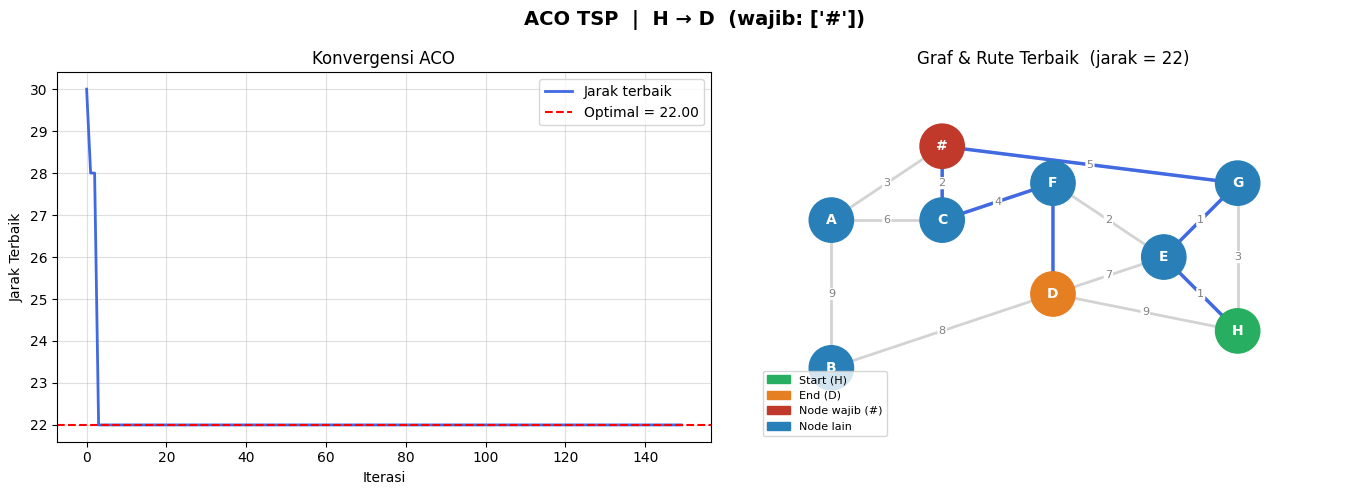


  Grafik disimpan sebagai 'hasil_aco_tsp.png'


In [ ]:

"""
=============================================================================
  Traveling Salesman Problem (TSP) dengan Ant Colony Optimization (ACO)
  Graf: A, B, C, D, E, F, G, H, #
  Kasus: Rute dari H ke D, wajib melewati node '#'
=============================================================================
"""

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Seed untuk reproduksibilitas hasil
random.seed(42)
np.random.seed(42)

# =============================================================================
# 1. MEMBANGUN GRAF & MATRIKS JARAK
# =============================================================================

# Daftar semua node
KOTA = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', '#']
N    = len(KOTA)
IDX  = {k: i for i, k in enumerate(KOTA)}
INF  = 1e9

# Matriks jarak langsung (edge yang ada di gambar)
dist = np.full((N, N), INF)
np.fill_diagonal(dist, 0)

# Edge graf (tidak berarah) — sesuai gambar
EDGES = [
    ('#', 'A', 3), ('#', 'C', 2), ('#', 'G', 5),
    ('A', 'B', 9), ('A', 'C', 6),
    ('B', 'D', 8),
    ('C', 'F', 4),
    ('D', 'E', 7), ('D', 'H', 9),
    ('E', 'F', 2), ('E', 'G', 1), ('E', 'H', 1),
    ('G', 'H', 3),
]

for (u, v, w) in EDGES:
    i, j = IDX[u], IDX[v]
    dist[i][j] = w
    dist[j][i] = w

# -------------------------------------------------------------------------
# Floyd-Warshall: jarak terpendek antara semua pasangan node
# -------------------------------------------------------------------------
shortest = dist.copy()
for k in range(N):
    for i in range(N):
        if shortest[i][k] == INF:
            continue
        for j in range(N):
            if shortest[k][j] == INF:
                continue
            if shortest[i][k] + shortest[k][j] < shortest[i][j]:
                shortest[i][j] = shortest[i][k] + shortest[k][j]

if np.any(shortest == INF):
    raise RuntimeError("Graf tidak terhubung sepenuhnya! Periksa kembali daftar edge.")

print("=" * 60)
print("  Matriks Jarak Terpendek Antar Node (Floyd-Warshall)")
print("=" * 60)
header = f"{'':>4}" + "".join(f"{k:>6}" for k in KOTA)
print(header)
for i, k in enumerate(KOTA):
    row = f"{k:>4}" + "".join(
        f"{'inf':>6}" if shortest[i][j] == INF else f"{shortest[i][j]:>6.0f}"
        for j in range(N)
    )
    print(row)

# =============================================================================
# 2. PARAMETER & INPUT PENGGUNA
# =============================================================================

print("\n" + "=" * 60)
print("  Konfigurasi Pencarian Rute")
print("=" * 60)
print(f"  Node tersedia : {KOTA}")

start_nama  = input("  Masukkan node awal    : ").strip().upper()
end_nama    = input("  Masukkan node akhir   : ").strip().upper()
wajib_input = input("  Node wajib dilewati (pisah koma, kosong jika tidak ada): ").strip().upper()

wajib_list = [x.strip() for x in wajib_input.split(',')] if wajib_input else []

# Validasi input
for nama in [start_nama, end_nama] + wajib_list:
    if nama and nama not in IDX:
        raise ValueError(f"Node '{nama}' tidak ada dalam graf!")

START         = IDX[start_nama]
END           = IDX[end_nama]
WAJIB_INDICES = [IDX[w] for w in wajib_list]

# =============================================================================
# 3. PARAMETER ACO
# =============================================================================

N_ANTS = 20    # jumlah semut per iterasi (ditambah dari 10 -> 20)
N_ITER = 150   # jumlah iterasi (ditambah dari 100 -> 150)
ALPHA  = 1.0   # bobot feromon
BETA   = 2.0   # bobot visibilitas (1/jarak)
RHO    = 0.5   # laju penguapan feromon
Q      = 1.0   # konstanta deposit feromon

# Matriks feromon awal (nilai kecil positif)
pheromone = np.full((N, N), 0.1)
np.fill_diagonal(pheromone, 0.0)

# =============================================================================
# 4. FUNGSI-FUNGSI ACO
# =============================================================================

def hitung_jarak_tur(tur: list) -> float:
    """Menghitung total jarak sebuah rute menggunakan matriks shortest path."""
    return sum(shortest[tur[i]][tur[i + 1]] for i in range(len(tur) - 1))


def semua_wajib_dikunjungi(tur: list) -> bool:
    """Memeriksa apakah semua node wajib sudah ada dalam rute."""
    return all(w in tur for w in WAJIB_INDICES)


def pilih_kota_berikutnya(sekarang: int, dikunjungi: list) -> int | None:
    """
    Memilih node berikutnya secara probabilistik berdasarkan:
      prob(i->j) ∝ tau(i,j)^alpha * eta(i,j)^beta
    di mana tau = feromon, eta = 1/jarak (visibilitas).
    Node yang sudah dikunjungi mendapat probabilitas 0.
    """
    prob = np.zeros(N)
    for calon in range(N):
        if not dikunjungi[calon] and shortest[sekarang][calon] < INF:
            tau = pheromone[sekarang][calon] ** ALPHA
            eta = (1.0 / shortest[sekarang][calon]) ** BETA
            prob[calon] = tau * eta

    total = prob.sum()
    if total == 0:
        # Fallback: pilih acak dari node yang belum dikunjungi
        belum = [k for k in range(N) if not dikunjungi[k]]
        return random.choice(belum) if belum else None

    prob /= total
    return int(np.random.choice(N, p=prob))


def bangun_tur() -> list:
    """
    Seekor semut membangun satu rute lengkap:
    - Mulai dari START
    - Berhenti saat mencapai END dan semua node wajib sudah dilewati
    - Jika sudah di END tapi belum semua node wajib dilalui, lanjut eksplorasi
    """
    tur       = [START]
    dikunjungi = [False] * N
    dikunjungi[START] = True
    max_langkah = N * 3   # batas maksimum langkah agar tidak infinite loop

    for _ in range(max_langkah):
        sekarang = tur[-1]
        # Kondisi berhenti
        if sekarang == END and semua_wajib_dikunjungi(tur):
            break
        berikutnya = pilih_kota_berikutnya(sekarang, dikunjungi)
        if berikutnya is None:
            break
        tur.append(berikutnya)
        dikunjungi[berikutnya] = True

    return tur


def update_pheromone(semua_tur: list, semua_jarak: list):
    global pheromone  # ← tambahkan baris ini
    pheromone *= (1 - RHO)
    for tur, jarak in zip(semua_tur, semua_jarak):
        if jarak == 0:
            continue
        deposit = Q / jarak
        for i in range(len(tur) - 1):
            a, b = tur[i], tur[i + 1]
            pheromone[a][b] += deposit
            pheromone[b][a] += deposit  # simetris

# =============================================================================
# 5. LOOP UTAMA ACO
# =============================================================================

best_tur   = None
best_jarak = float('inf')
history    = []   # riwayat jarak terbaik tiap iterasi

print("\n" + "=" * 60)
print(f"  Mencari rute: {start_nama} -> {end_nama}  |  Wajib: {wajib_list or 'tidak ada'}")
print(f"  Parameter: semut={N_ANTS}, iterasi={N_ITER}, alpha={ALPHA}, beta={BETA}, rho={RHO}")
print("=" * 60)

for it in range(N_ITER):
    semua_tur    = []
    semua_jarak  = []

    # Setiap semut membangun rute
    for _ in range(N_ANTS):
        tur   = bangun_tur()
        jarak = hitung_jarak_tur(tur)
        semua_tur.append(tur)
        semua_jarak.append(jarak)

        # Simpan sebagai best jika valid (mencapai END & semua wajib dilalui)
        if tur[-1] == END and semua_wajib_dikunjungi(tur) and jarak < best_jarak:
            best_jarak = jarak
            best_tur   = tur.copy()

    # Update feromon
    update_pheromone(semua_tur, semua_jarak)
    history.append(best_jarak if best_jarak < float('inf') else None)

    # Cetak progres setiap 30 iterasi
    if (it + 1) % 30 == 0:
        status = f"{best_jarak:.2f}" if best_jarak < float('inf') else "belum ditemukan"
        print(f"  Iterasi {it+1:>3d} | Jarak terbaik = {status}")

# =============================================================================
# 6. TAMPILKAN HASIL AKHIR
# =============================================================================

print("\n" + "=" * 60)
print("  HASIL RUTE TERPENDEK")
print("=" * 60)

if best_tur is None:
    print("  Rute tidak ditemukan. Periksa kembali node wajib & graf.")
else:
    rute_nama = [KOTA[i] for i in best_tur]
    print(f"  Rute   : {' -> '.join(rute_nama)}")
    print(f"  Jarak  : {best_jarak:.2f}")

    # Detail per segmen
    print("\n  Detail segmen:")
    for i in range(len(best_tur) - 1):
        a, b = best_tur[i], best_tur[i + 1]
        print(f"    {KOTA[a]} -> {KOTA[b]}  : {shortest[a][b]:.0f}")

print("=" * 60)

# =============================================================================
# 7. VISUALISASI
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"ACO TSP  |  {start_nama} → {end_nama}  (wajib: {wajib_list})",
    fontsize=14, fontweight='bold'
)

# --- Plot 1: Grafik Konvergensi ---
ax1 = axes[0]
valid_history = [v for v in history if v is not None]
valid_iter    = [i for i, v in enumerate(history) if v is not None]

ax1.plot(valid_iter, valid_history, color='royalblue', linewidth=2, label='Jarak terbaik')
ax1.axhline(y=best_jarak, color='red', linestyle='--', linewidth=1.5,
            label=f'Optimal = {best_jarak:.2f}')
ax1.set_title('Konvergensi ACO')
ax1.set_xlabel('Iterasi')
ax1.set_ylabel('Jarak Terbaik')
ax1.legend()
ax1.grid(True, alpha=0.4)

# --- Plot 2: Visualisasi Graf & Rute ---
ax2 = axes[1]

# Posisi node di layout (disesuaikan dengan gambar soal)
pos = {
    '#': (2.5, 4.0),
    'A': (1.0, 3.0),
    'B': (1.0, 1.0),
    'C': (2.5, 3.0),
    'D': (4.0, 2.0),
    'E': (5.5, 2.5),
    'F': (4.0, 3.5),
    'G': (6.5, 3.5),
    'H': (6.5, 1.5),
}

# Gambar semua edge (abu-abu)
for (u, v, w) in EDGES:
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    ax2.plot([x1, x2], [y1, y2], color='lightgray', linewidth=2, zorder=1)
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax2.text(mx, my, str(w), fontsize=8, ha='center', va='center',
             color='gray', bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none'))

# Gambar edge rute terbaik (biru tebal)
if best_tur:
    for i in range(len(best_tur) - 1):
        u_name = KOTA[best_tur[i]]
        v_name = KOTA[best_tur[i + 1]]
        x1, y1 = pos[u_name]
        x2, y2 = pos[v_name]
        ax2.annotate('', xy=(x2, y2), xytext=(x1, y1),
                     arrowprops=dict(arrowstyle='->', color='royalblue',
                                     lw=2.5), zorder=2)

# Gambar node
for nama, (x, y) in pos.items():
    if nama == '#':
        color = '#c0392b'        # merah untuk node '#'
    elif nama == start_nama:
        color = '#27ae60'        # hijau untuk start
    elif nama == end_nama:
        color = '#e67e22'        # oranye untuk end
    elif nama in wajib_list:
        color = '#8e44ad'        # ungu untuk wajib
    else:
        color = '#2980b9'        # biru untuk node biasa

    circle = plt.Circle((x, y), 0.3, color=color, zorder=3)
    ax2.add_patch(circle)
    ax2.text(x, y, nama, ha='center', va='center',
             fontsize=10, fontweight='bold', color='white', zorder=4)

ax2.set_xlim(0, 8)
ax2.set_ylim(0, 5)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title(f"Graf & Rute Terbaik  (jarak = {best_jarak:.0f})")

# Legend
legend_items = [
    mpatches.Patch(color='#27ae60', label=f'Start ({start_nama})'),
    mpatches.Patch(color='#e67e22', label=f'End ({end_nama})'),
    mpatches.Patch(color='#c0392b', label='Node wajib (#)'),
    mpatches.Patch(color='#2980b9', label='Node lain'),
]
ax2.legend(handles=legend_items, loc='lower left', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hasil_aco_tsp.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Grafik disimpan sebagai 'hasil_aco_tsp.png'")
